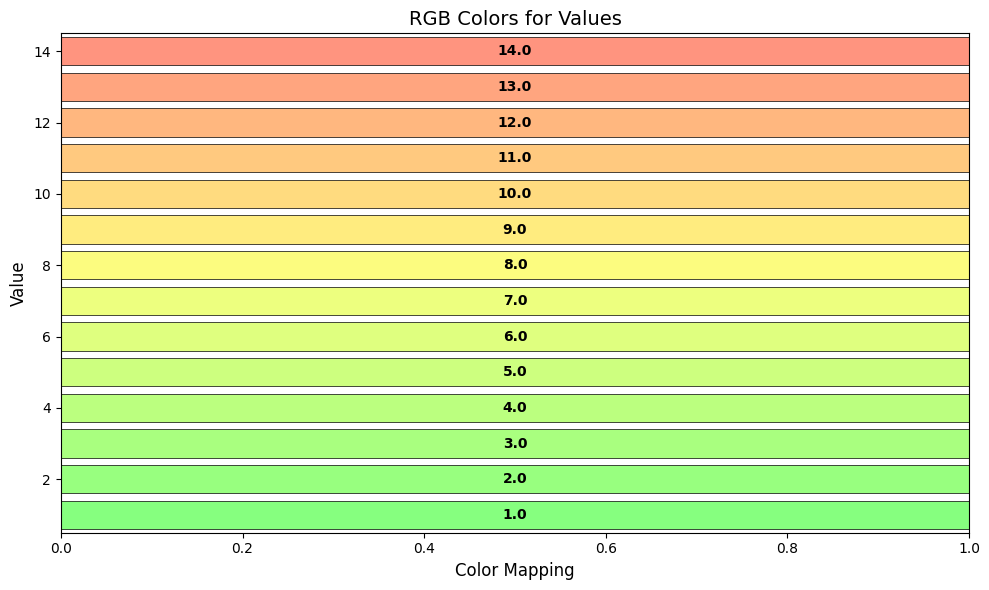

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.colors import Colormap
import numpy as np

def get_rbg_colors(
        cmap: Colormap,
        value: float,
        min_val: float,
        max_val: float,
        cmap_min: float,
        cmap_max: float,
        alpha: float,
        invert_cmap: bool = False):
    if invert_cmap:
        norm_val = (value - max_val) / (min_val - max_val)
    else:
        norm_val = (value - min_val) / (max_val - min_val)
    mapped_value = norm_val * (cmap_max - cmap_min) + cmap_min
    color = cmap(mapped_value)
    r, g, b = [int(255 * (c * (1 - alpha) + alpha)) for c in color[:3]]
    # bg = f'rgb({r}, {g}, {b})'
    return r, g, b

cmap = plt.get_cmap('hsv')
min_val = 1.0
max_val = 14.0
cmap_min = 0.03
cmap_max = 0.33
alpha = 0.5
invert_cmap = True

val_list = np.arange(min_val, max_val+1)

# Compute RGB colors for all values in val_list
colors_rgb = []
for val in val_list:
    r, g, b = get_rbg_colors(
        cmap=cmap,
        value=val,
        min_val=min_val,
        max_val=max_val,
        cmap_min=cmap_min,
        cmap_max=cmap_max,
        alpha=alpha,
        invert_cmap=invert_cmap
    )
    # Normalize to 0-1 range for matplotlib
    colors_rgb.append((r/255, g/255, b/255))

# Create a horizontal bar chart with colors
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(val_list, [1]*len(val_list), color=colors_rgb, edgecolor='black', linewidth=0.5)

# Add value labels on the bars
for i, val in enumerate(val_list):
    ax.text(0.5, val, f'{val:.1f}', ha='center', va='center', fontweight='bold', fontsize=10)

ax.set_xlabel('Color Mapping', fontsize=12)
ax.set_ylabel('Value', fontsize=12)
ax.set_title('RGB Colors for Values', fontsize=14)
ax.set_xlim(0, 1)
ax.set_ylim(min_val - 0.5, max_val + 0.5)
plt.tight_layout()
plt.show()

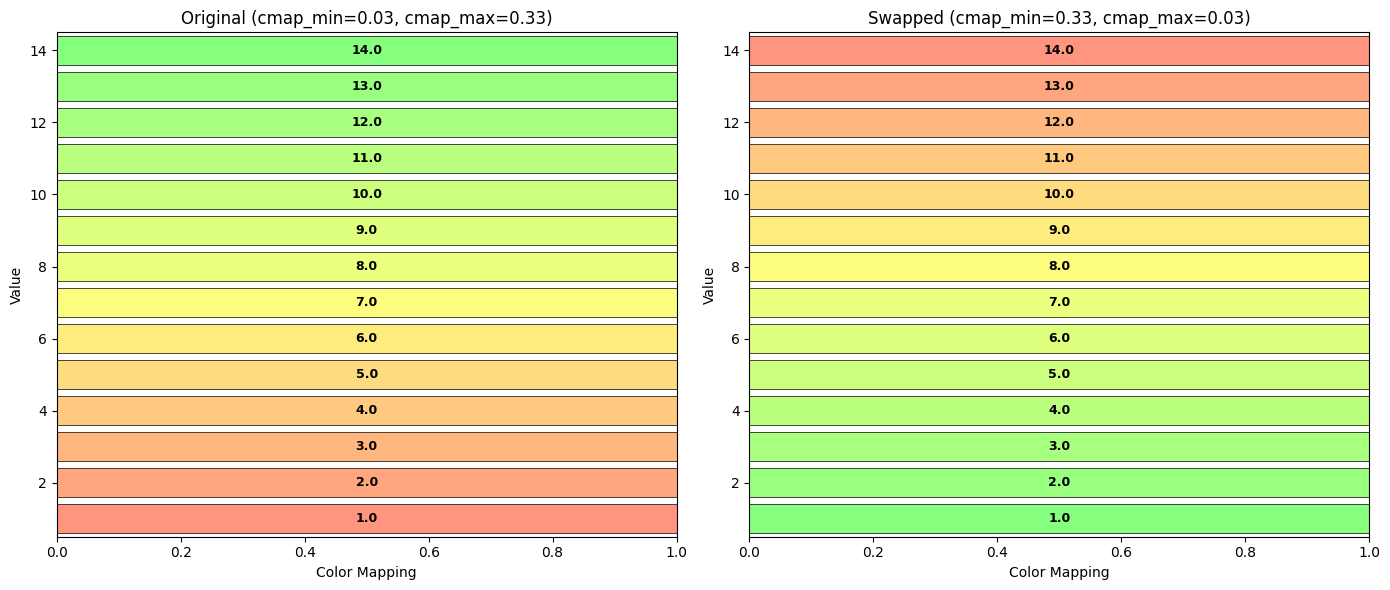

Color comparison at extremes:
Value 1.0: Original=(1.0, 0.5803921568627451, 0.4980392156862745), Swapped=(0.5254901960784314, 1.0, 0.4980392156862745)
Value 14.0: Original=(0.5254901960784314, 1.0, 0.4980392156862745), Swapped=(1.0, 0.5803921568627451, 0.4980392156862745)


In [24]:
# Test inversion: compare original vs swapped cmap_min/cmap_max
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Current version (swapped values)
colors_current = []
for val in val_list:
    r, g, b = get_rbg_colors(
        cmap=cmap,
        value=val,
        min_val=min_val,
        max_val=max_val,
        cmap_min=cmap_min,
        cmap_max=cmap_max,
        alpha=alpha,
        invert_cmap=True
    )
    colors_current.append((r/255, g/255, b/255))

# Original version (before swap)
colors_original = []
for val in val_list:
    r, g, b = get_rbg_colors(
        cmap=cmap,
        value=val,
        min_val=min_val,
        max_val=max_val,
        cmap_min=cmap_min,
        cmap_max=cmap_max,
        alpha=alpha
    )
    colors_original.append((r/255, g/255, b/255))

# Plot original
ax1.barh(val_list, [1]*len(val_list), color=colors_original, edgecolor='black', linewidth=0.5)
for i, val in enumerate(val_list):
    ax1.text(0.5, val, f'{val:.1f}', ha='center', va='center', fontweight='bold', fontsize=9)
ax1.set_xlabel('Color Mapping')
ax1.set_ylabel('Value')
ax1.set_title('Original (cmap_min=0.03, cmap_max=0.33)')
ax1.set_xlim(0, 1)
ax1.set_ylim(min_val - 0.5, max_val + 0.5)

# Plot current (swapped)
ax2.barh(val_list, [1]*len(val_list), color=colors_current, edgecolor='black', linewidth=0.5)
for i, val in enumerate(val_list):
    ax2.text(0.5, val, f'{val:.1f}', ha='center', va='center', fontweight='bold', fontsize=9)
ax2.set_xlabel('Color Mapping')
ax2.set_ylabel('Value')
ax2.set_title('Swapped (cmap_min=0.33, cmap_max=0.03)')
ax2.set_xlim(0, 1)
ax2.set_ylim(min_val - 0.5, max_val + 0.5)

plt.tight_layout()
plt.show()

# Print color comparison at extremes
print("Color comparison at extremes:")
print(f"Value {min_val}: Original={colors_original[0]}, Swapped={colors_current[0]}")
print(f"Value {max_val}: Original={colors_original[-1]}, Swapped={colors_current[-1]}")

In [6]:
import numpy as np
import soundfile as sf

filepath_audio = 'audio_debugging/amp_mod_short.wav'
filepath_calibnoise = 'calib_noise.wav'

audio, fs1 = sf.read(filepath_audio)
noise, fs2 = sf.read(filepath_calibnoise)

def rms(audio):
    return np.sqrt(np.mean(audio**2, axis=0))

def to_db(val):
    return 20*np.log10(val)

print(to_db(rms(audio[:round(1*fs1)])))
print(to_db(rms(noise[:round(1*fs2)])))

[-29.42531103 -29.42531103]
-48.972820290183854
